Calculating accuracies for all methods...


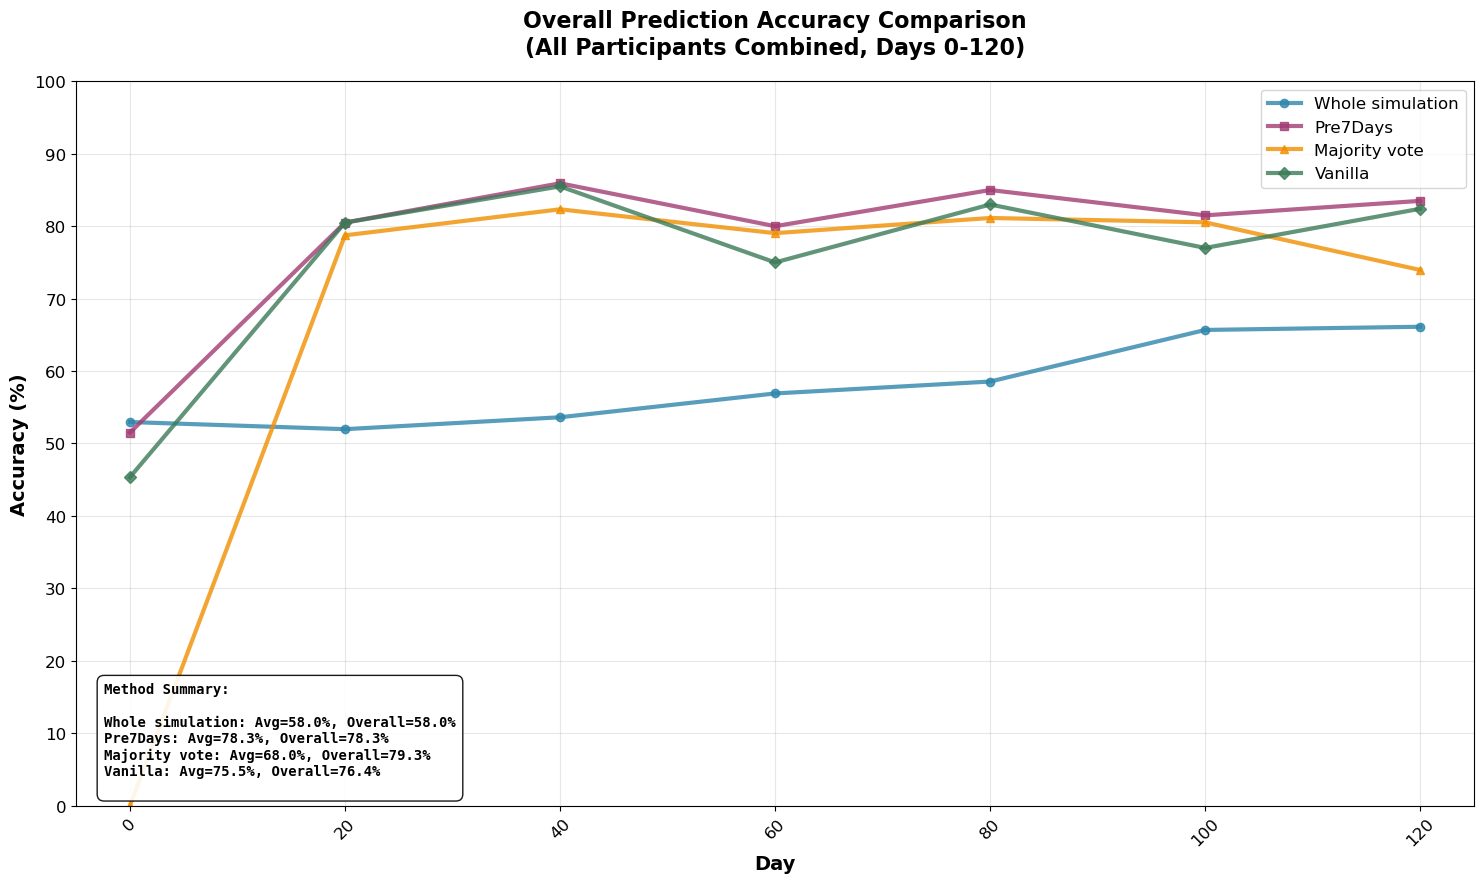


DETAILED ACCURACY STATISTICS

Whole simulation:
  Average Daily Accuracy: 58.0%
  Overall Accuracy: 58.0%
  Total Predictions: 2,127
  Total Correct: 1,233
  Key Day Accuracies:
    Day 0: 53.0%
    Day 40: 53.6%
    Day 80: 58.6%
    Day 120: 66.1%

Pre7Days:
  Average Daily Accuracy: 78.3%
  Overall Accuracy: 78.3%
  Total Predictions: 1,399
  Total Correct: 1,095
  Key Day Accuracies:
    Day 0: 51.5%
    Day 40: 85.9%
    Day 80: 85.0%
    Day 120: 83.5%

Majority vote:
  Average Daily Accuracy: 68.0%
  Overall Accuracy: 79.3%
  Total Predictions: 2,004
  Total Correct: 1,589
  Key Day Accuracies:
    Day 0: 0.0%
    Day 40: 82.3%
    Day 80: 81.1%
    Day 120: 74.0%

Vanilla:
  Average Daily Accuracy: 75.5%
  Overall Accuracy: 76.4%
  Total Predictions: 1,360
  Total Correct: 1,039
  Key Day Accuracies:
    Day 0: 45.3%
    Day 40: 85.5%
    Day 80: 83.0%
    Day 120: 82.4%


In [ ]:
import json
from huggingface_hub import snapshot_download
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set style for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Configuration
DAYS = [0, 20, 40, 60, 80, 100, 120]

def load_ground_truth():
    """Load ground truth data from participants_data.json"""
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        return json.load(f)

def get_actual_label(pid: str, day: int):
    """Get ground truth label for a participant on a specific day."""
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        participants = json.load(f)
    
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed):
    """Extract decision and confidence from LLM response."""
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# =============================================================================
# 1. Whole Simulation Accuracy
# =============================================================================
def calculate_whole_simulation_accuracy():
    """Calculate accuracy for Whole simulation trajectory"""
    trajectory_dir = Path("traj_0")
    predictions_data = {}
    
    for participant_dir in trajectory_dir.iterdir():
        if participant_dir.is_dir():
            participant_id = participant_dir.name
            predictions_file = participant_dir / "predictions.json"
            
            if predictions_file.exists():
                with open(predictions_file, 'r', encoding='utf-8') as f:
                    predictions_data[participant_id] = json.load(f)
    
    ground_truth_data = load_ground_truth()
    accuracy_data = []
    
    for day in DAYS:
        correct_predictions = 0
        total_predictions = 0
        
        for participant_id, predictions in predictions_data.items():
            if participant_id not in ground_truth_data:
                continue
                
            gt_mood_data = ground_truth_data[participant_id].get("Mood", {})
            prediction = next((p for p in predictions if p.get("day") == day), None)
            
            if prediction and "model_response_parsed" in prediction:
                parsed = prediction["model_response_parsed"]
                if parsed is None:
                    continue
                    
                mood_completion = parsed.get("mood_completion", "missing")
                day_key = f"Day {day}"
                is_missing_gt = day_key not in gt_mood_data
                is_missing_llm = mood_completion == "missing"
                
                if is_missing_llm == is_missing_gt:
                    correct_predictions += 1
                total_predictions += 1
        
        accuracy = (correct_predictions / total_predictions) if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': correct_predictions,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 2. Pre7Days Accuracy
# =============================================================================
def calculate_pre7days_accuracy():
    """Calculate accuracy for pre7days predictions"""
    HF_REPO_ID = "nichenshun/rdmap_predictions_pre7days_activity"  
    HF_CACHE_DIR = Path("./hf_cache")  
    PREDICTIONS_DIR = Path(snapshot_download(  
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        cache_dir=HF_CACHE_DIR,
    ))
    accuracy_data = []
    
    for day in DAYS:
        total_correct = 0
        total_predictions = 0
        
        for role in ["patients", "caregivers"]:
            pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
            if not pred_file.exists():
                continue

            with pred_file.open("r", encoding="utf-8") as f:
                preds_dict = json.load(f)

            if not isinstance(preds_dict, dict):
                continue

            for pid, rec in preds_dict.items():
                parsed = rec.get("model_response_parsed")
                if parsed is None:
                    raw = rec.get("model_response_raw", "")
                    try:
                        parsed = json.loads(raw)
                    except Exception:
                        continue

                info = extract_decision_and_conf(parsed)
                if info is None:
                    continue

                y_hat = info["y_hat"]
                y_true = get_actual_label(pid, day)
                if y_true is None:
                    continue

                if y_hat == y_true:
                    total_correct += 1
                total_predictions += 1

        accuracy = total_correct / total_predictions if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': total_correct,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 3. Majority Vote Accuracy
# =============================================================================
def calculate_majority_vote_accuracy():
    """Calculate accuracy for majority vote predictions"""
    PRED_CSV = Path("majority_vote_predictions.csv")
    df = pd.read_csv(PRED_CSV)
    df_key_days = df[df["day"].isin(DAYS)].copy()
    
    accuracy_data = []
    
    for day in DAYS:
        day_data = df_key_days[df_key_days["day"] == day]
        if len(day_data) == 0:
            accuracy_data.append({'day': day, 'accuracy': 0, 'correct_predictions': 0, 'total_predictions': 0})
            continue
            
        correct = ((day_data["pred"] == "Yes") & (day_data["true"] == "Yes")).sum() + \
                  ((day_data["pred"] == "No") & (day_data["true"] == "No")).sum()
        total = len(day_data)
        accuracy = correct / total if total > 0 else 0
        
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': correct,
            'total_predictions': total
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 4. Vanilla Accuracy
# =============================================================================
def calculate_vanilla_accuracy():
    """Calculate accuracy for vanilla predictions"""
    # PREDICTIONS_DIR = Path("predictions_vanilla")
    HF_REPO_ID = "nichenshun/rdmap_predictions_vanilla"  
    HF_CACHE_DIR = Path("./hf_cache")  
    PREDICTIONS_DIR = Path(snapshot_download(  
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        cache_dir=HF_CACHE_DIR,
    ))
    accuracy_data = []
    
    for day in DAYS:
        total_correct = 0
        total_predictions = 0
        
        for role in ["patients", "caregivers"]:
            pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
            if not pred_file.exists():
                continue

            with pred_file.open("r", encoding="utf-8") as f:
                preds_dict = json.load(f)

            if not isinstance(preds_dict, dict):
                continue

            for pid, rec in preds_dict.items():
                parsed = rec.get("model_response_parsed")
                if parsed is None:
                    raw = rec.get("model_response_raw", "")
                    try:
                        parsed = json.loads(raw)
                    except Exception:
                        continue

                info = extract_decision_and_conf(parsed)
                if info is None:
                    continue

                y_hat = info["y_hat"]
                y_true = get_actual_label(pid, day)
                if y_true is None:
                    continue

                if y_hat == y_true:
                    total_correct += 1
                total_predictions += 1

        accuracy = total_correct / total_predictions if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': total_correct,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# Main Execution - Combined Plot
# =============================================================================
def main():
    print("Calculating accuracies for all methods...")
    
    # Calculate accuracies for all methods
    whole_sim_df = calculate_whole_simulation_accuracy()
    pre7days_df = calculate_pre7days_accuracy()
    majority_df = calculate_majority_vote_accuracy()
    vanilla_df = calculate_vanilla_accuracy()
    
    # Create combined plot
    plt.figure(figsize=(15, 9))
    
    # Plot all methods
    plt.plot(whole_sim_df['day'], whole_sim_df['accuracy'] * 100, 
             marker='o', linewidth=3, markersize=6, 
             color='#2E86AB', label='Whole simulation', alpha=0.8)
    
    plt.plot(pre7days_df['day'], pre7days_df['accuracy'] * 100, 
             marker='s', linewidth=3, markersize=6, 
             color='#A23B72', label='Pre7Days', alpha=0.8)
    
    plt.plot(majority_df['day'], majority_df['accuracy'] * 100, 
             marker='^', linewidth=3, markersize=6, 
             color='#F18F01', label='Majority vote', alpha=0.8)
    
    plt.plot(vanilla_df['day'], vanilla_df['accuracy'] * 100, 
             marker='D', linewidth=3, markersize=6, 
             color='#3B7A57', label='Vanilla', alpha=0.8)
    
    # Customize the plot
    plt.title('Overall Prediction Accuracy Comparison\n(All Participants Combined, Days 0-120)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Day', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Set axis limits and ticks
    plt.xlim(-5, 125)
    plt.ylim(0, 100)
    plt.xticks(DAYS, rotation=45)
    plt.yticks(range(0, 101, 10))
    
    # Add legend
    plt.legend(loc='best', fontsize=12)
    
    # Add statistics table
    methods = ['Whole simulation', 'Pre7Days', 'Majority vote', 'Vanilla']
    dataframes = [whole_sim_df, pre7days_df, majority_df, vanilla_df]
    
    stats_data = []
    for method, df in zip(methods, dataframes):
        avg_acc = df['accuracy'].mean() * 100
        total_pred = df['total_predictions'].sum()
        total_correct = df['correct_predictions'].sum()
        overall_acc = (total_correct / total_pred * 100) if total_pred > 0 else 0
        
        stats_data.append([method, f'{avg_acc:.1f}%', f'{overall_acc:.1f}%', f'{total_pred:,}'])
    
    # Create statistics text
    stats_text = "Method Summary:\n\n"
    for method, avg_acc, overall_acc, total_pred in stats_data:
        stats_text += f"{method}: Avg={avg_acc}, Overall={overall_acc}\n"
    
    plt.annotate(stats_text, xy=(0.02, 0.02), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9),
                fontsize=10, fontweight='bold', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*80)
    print("DETAILED ACCURACY STATISTICS")
    print("="*80)
    
    for method, df in zip(methods, dataframes):
        avg_acc = df['accuracy'].mean() * 100
        total_pred = df['total_predictions'].sum()
        total_correct = df['correct_predictions'].sum()
        overall_acc = (total_correct / total_pred * 100) if total_pred > 0 else 0
        
        print(f"\n{method}:")
        print(f"  Average Daily Accuracy: {avg_acc:.1f}%")
        print(f"  Overall Accuracy: {overall_acc:.1f}%")
        print(f"  Total Predictions: {total_pred:,}")
        print(f"  Total Correct: {total_correct:,}")
        
        # Print accuracy for key days
        print("  Key Day Accuracies:")
        for day in [0, 40, 80, 120]:
            day_data = df[df['day'] == day]
            if len(day_data) > 0:
                acc = day_data['accuracy'].values[0] * 100
                print(f"    Day {day}: {acc:.1f}%")

if __name__ == "__main__":
    main()

Calculating accuracies for all methods...

ACCURACY COMPARISON TABLE (All Participants Combined)
    Day Whole simulation Pre7Days Majority vote Vanilla
      0            0.530    0.515         0.000   0.453
     20            0.520    0.805         0.787   0.805
     40            0.536    0.859         0.823   0.855
     60            0.569    0.800         0.790   0.750
     80            0.586    0.850         0.811   0.830
    100            0.657    0.815         0.805   0.770
    120            0.661    0.835         0.740   0.824
Average            0.580    0.783         0.680   0.755

SUMMARY STATISTICS
          Method Avg Accuracy Overall Accuracy Total Predictions Total Correct
Whole simulation        0.580            0.580             2,127         1,233
        Pre7Days        0.783            0.783             1,399         1,095
   Majority vote        0.680            0.793             2,004         1,589
         Vanilla        0.755            0.764             1,36

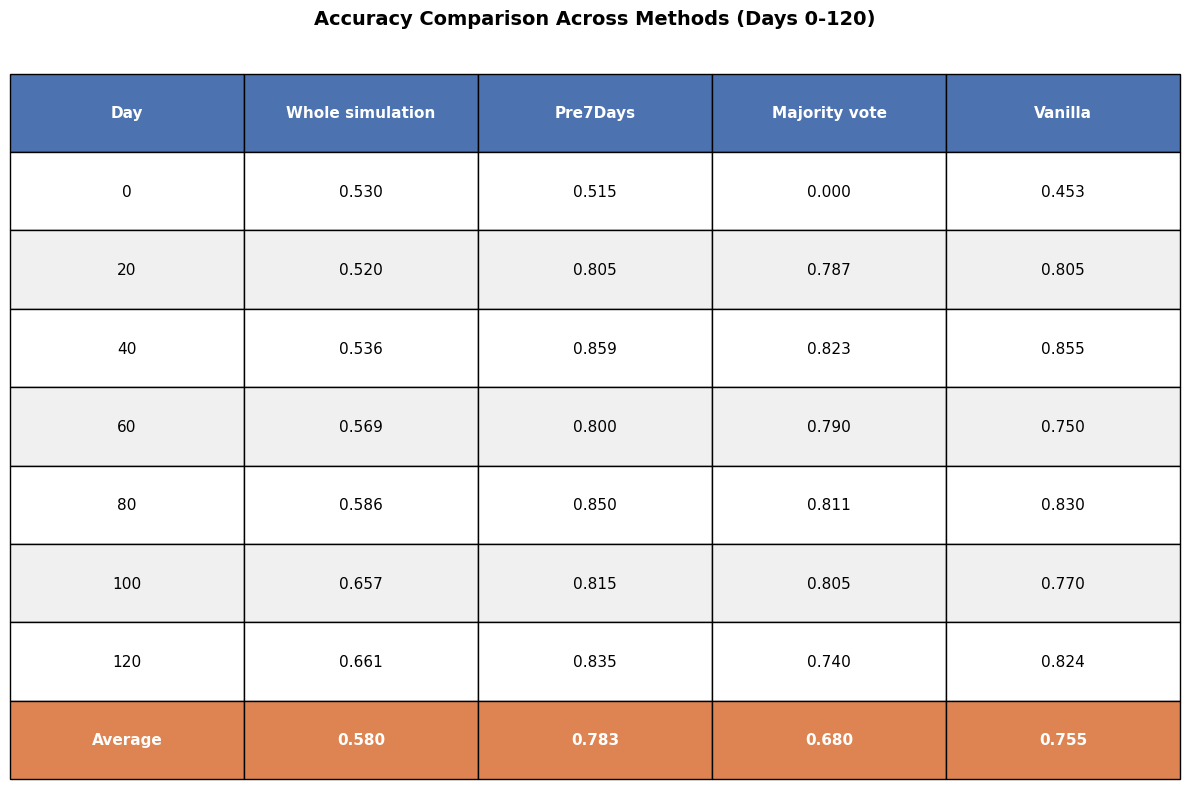

Calculating accuracies for all methods...

Data exported to CSV files:
  - accuracy_comparison_summary.csv
  - whole_simulation_accuracy_detailed.csv
  - pre7days_accuracy_detailed.csv
  - majority_vote_accuracy_detailed.csv
  - vanilla_accuracy_detailed.csv

ADDITIONAL ANALYSIS
Calculating accuracies for all methods...

Best Performing Method by Day:
----------------------------------------
Day   0: Whole simulation (0.530)
Day  20: Pre7Days (0.805)
Day  40: Pre7Days (0.859)
Day  60: Pre7Days (0.800)
Day  80: Pre7Days (0.850)
Day 100: Pre7Days (0.815)
Day 120: Pre7Days (0.835)


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set style for better visualization
plt.style.use('default')
plt.rcParams['font.size'] = 10

# Configuration
DAYS = [0, 20, 40, 60, 80, 100, 120]

def load_ground_truth():
    """Load ground truth data from participants_data.json"""
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        return json.load(f)

def get_actual_label(pid: str, day: int):
    """Get ground truth label for a participant on a specific day."""
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        participants = json.load(f)
    
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed):
    """Extract decision and confidence from LLM response."""
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# =============================================================================
# 1. Whole Simulation Accuracy
# =============================================================================
def calculate_whole_simulation_accuracy():
    """Calculate accuracy for Whole simulation trajectory"""
    trajectory_dir = Path("traj_0")
    predictions_data = {}
    
    for participant_dir in trajectory_dir.iterdir():
        if participant_dir.is_dir():
            participant_id = participant_dir.name
            predictions_file = participant_dir / "predictions.json"
            
            if predictions_file.exists():
                with open(predictions_file, 'r', encoding='utf-8') as f:
                    predictions_data[participant_id] = json.load(f)
    
    ground_truth_data = load_ground_truth()
    accuracy_data = []
    
    for day in DAYS:
        correct_predictions = 0
        total_predictions = 0
        
        for participant_id, predictions in predictions_data.items():
            if participant_id not in ground_truth_data:
                continue
                
            gt_mood_data = ground_truth_data[participant_id].get("Mood", {})
            prediction = next((p for p in predictions if p.get("day") == day), None)
            
            if prediction and "model_response_parsed" in prediction:
                parsed = prediction["model_response_parsed"]
                if parsed is None:
                    continue
                    
                mood_completion = parsed.get("mood_completion", "missing")
                day_key = f"Day {day}"
                is_missing_gt = day_key not in gt_mood_data
                is_missing_llm = mood_completion == "missing"
                
                if is_missing_llm == is_missing_gt:
                    correct_predictions += 1
                total_predictions += 1
        
        accuracy = (correct_predictions / total_predictions) if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': correct_predictions,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 2. Pre7Days Accuracy
# =============================================================================
def calculate_pre7days_accuracy():
    """Calculate accuracy for pre7days predictions"""
    PREDICTIONS_DIR = Path("predictions_pre7days_activity")
    accuracy_data = []
    
    for day in DAYS:
        total_correct = 0
        total_predictions = 0
        
        for role in ["patients", "caregivers"]:
            pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
            if not pred_file.exists():
                continue

            with pred_file.open("r", encoding="utf-8") as f:
                preds_dict = json.load(f)

            if not isinstance(preds_dict, dict):
                continue

            for pid, rec in preds_dict.items():
                parsed = rec.get("model_response_parsed")
                if parsed is None:
                    raw = rec.get("model_response_raw", "")
                    try:
                        parsed = json.loads(raw)
                    except Exception:
                        continue

                info = extract_decision_and_conf(parsed)
                if info is None:
                    continue

                y_hat = info["y_hat"]
                y_true = get_actual_label(pid, day)
                if y_true is None:
                    continue

                if y_hat == y_true:
                    total_correct += 1
                total_predictions += 1

        accuracy = total_correct / total_predictions if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': total_correct,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 3. Majority Vote Accuracy
# =============================================================================
def calculate_majority_vote_accuracy():
    """Calculate accuracy for majority vote predictions"""
    PRED_CSV = Path("majority_vote_predictions.csv")
    df = pd.read_csv(PRED_CSV)
    df_key_days = df[df["day"].isin(DAYS)].copy()
    
    accuracy_data = []
    
    for day in DAYS:
        day_data = df_key_days[df_key_days["day"] == day]
        if len(day_data) == 0:
            accuracy_data.append({'day': day, 'accuracy': 0, 'correct_predictions': 0, 'total_predictions': 0})
            continue
            
        correct = ((day_data["pred"] == "Yes") & (day_data["true"] == "Yes")).sum() + \
                  ((day_data["pred"] == "No") & (day_data["true"] == "No")).sum()
        total = len(day_data)
        accuracy = correct / total if total > 0 else 0
        
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': correct,
            'total_predictions': total
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# 4. Vanilla Accuracy
# =============================================================================
def calculate_vanilla_accuracy():
    """Calculate accuracy for vanilla predictions"""
    PREDICTIONS_DIR = Path("predictions_vanilla")
    accuracy_data = []
    
    for day in DAYS:
        total_correct = 0
        total_predictions = 0
        
        for role in ["patients", "caregivers"]:
            pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
            if not pred_file.exists():
                continue

            with pred_file.open("r", encoding="utf-8") as f:
                preds_dict = json.load(f)

            if not isinstance(preds_dict, dict):
                continue

            for pid, rec in preds_dict.items():
                parsed = rec.get("model_response_parsed")
                if parsed is None:
                    raw = rec.get("model_response_raw", "")
                    try:
                        parsed = json.loads(raw)
                    except Exception:
                        continue

                info = extract_decision_and_conf(parsed)
                if info is None:
                    continue

                y_hat = info["y_hat"]
                y_true = get_actual_label(pid, day)
                if y_true is None:
                    continue

                if y_hat == y_true:
                    total_correct += 1
                total_predictions += 1

        accuracy = total_correct / total_predictions if total_predictions > 0 else 0
        accuracy_data.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': total_correct,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(accuracy_data)

# =============================================================================
# Create Accuracy Table
# =============================================================================
def create_accuracy_table():
    """Create a comprehensive accuracy table for all methods"""
    print("Calculating accuracies for all methods...")
    
    # Calculate accuracies for all methods
    whole_sim_df = calculate_whole_simulation_accuracy()
    pre7days_df = calculate_pre7days_accuracy()
    majority_df = calculate_majority_vote_accuracy()
    vanilla_df = calculate_vanilla_accuracy()
    
    # Create summary table
    summary_data = []
    
    for day in DAYS:
        row = {'Day': day}
        
        # Whole simulation
        whole_day_data = whole_sim_df[whole_sim_df['day'] == day]
        if len(whole_day_data) > 0:
            row['Whole simulation'] = f"{whole_day_data['accuracy'].values[0]:.3f}"
        else:
            row['Whole simulation'] = "N/A"
        
        # Pre7Days
        pre7_day_data = pre7days_df[pre7days_df['day'] == day]
        if len(pre7_day_data) > 0:
            row['Pre7Days'] = f"{pre7_day_data['accuracy'].values[0]:.3f}"
        else:
            row['Pre7Days'] = "N/A"
        
        # Majority Vote
        majority_day_data = majority_df[majority_df['day'] == day]
        if len(majority_day_data) > 0:
            row['Majority vote'] = f"{majority_day_data['accuracy'].values[0]:.3f}"
        else:
            row['Majority vote'] = "N/A"
        
        # Vanilla
        vanilla_day_data = vanilla_df[vanilla_df['day'] == day]
        if len(vanilla_day_data) > 0:
            row['Vanilla'] = f"{vanilla_day_data['accuracy'].values[0]:.3f}"
        else:
            row['Vanilla'] = "N/A"
        
        summary_data.append(row)
    
    # Create DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    # Add average row
    avg_row = {'Day': 'Average'}
    methods = ['Whole simulation', 'Pre7Days', 'Majority vote', 'Vanilla']
    dataframes = [whole_sim_df, pre7days_df, majority_df, vanilla_df]
    
    for method, df in zip(methods, dataframes):
        if len(df) > 0:
            avg_acc = df['accuracy'].mean()
            avg_row[method] = f"{avg_acc:.3f}"
        else:
            avg_row[method] = "N/A"
    
    summary_df = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
    
    return summary_df, whole_sim_df, pre7days_df, majority_df, vanilla_df

# =============================================================================
# Display Results
# =============================================================================
def display_results():
    """Display the accuracy table and statistics"""
    summary_df, whole_sim_df, pre7days_df, majority_df, vanilla_df = create_accuracy_table()
    
    # Print detailed table
    print("\n" + "="*90)
    print("ACCURACY COMPARISON TABLE (All Participants Combined)")
    print("="*90)
    print(summary_df.to_string(index=False))
    
    # Print summary statistics
    print("\n" + "="*90)
    print("SUMMARY STATISTICS")
    print("="*90)
    
    methods = ['Whole simulation', 'Pre7Days', 'Majority vote', 'Vanilla']
    dataframes = [whole_sim_df, pre7days_df, majority_df, vanilla_df]
    
    stats_data = []
    for method, df in zip(methods, dataframes):
        if len(df) > 0:
            avg_acc = df['accuracy'].mean()
            total_pred = df['total_predictions'].sum()
            total_correct = df['correct_predictions'].sum()
            overall_acc = (total_correct / total_pred) if total_pred > 0 else 0
            
            stats_data.append({
                'Method': method,
                'Avg Accuracy': f"{avg_acc:.3f}",
                'Overall Accuracy': f"{overall_acc:.3f}",
                'Total Predictions': f"{total_pred:,}",
                'Total Correct': f"{total_correct:,}"
            })
    
    stats_df = pd.DataFrame(stats_data)
    print(stats_df.to_string(index=False))
    
    # Create visual table
    create_visual_table(summary_df)

def create_visual_table(summary_df):
    """Create a visually appealing table using matplotlib"""
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('tight')
    ax.axis('off')
    
    # Create table
    table = ax.table(cellText=summary_df.values,
                    colLabels=summary_df.columns,
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    
    # Color header row
    for i in range(len(summary_df.columns)):
        table[(0, i)].set_facecolor('#4C72B0')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color average row
    last_row = len(summary_df)
    for i in range(len(summary_df.columns)):
        table[(last_row, i)].set_facecolor('#DD8452')
        table[(last_row, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(summary_df)-1):
        for j in range(len(summary_df.columns)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#F0F0F0')
    
    plt.title('Accuracy Comparison Across Methods (Days 0-120)\n', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# =============================================================================
# Export to CSV
# =============================================================================
def export_to_csv():
    """Export the accuracy data to CSV files"""
    summary_df, whole_sim_df, pre7days_df, majority_df, vanilla_df = create_accuracy_table()
    
    # Export summary table
    summary_df.to_csv('accuracy_comparison_summary.csv', index=False)
    
    # Export detailed data for each method
    whole_sim_df.to_csv('whole_simulation_accuracy_detailed.csv', index=False)
    pre7days_df.to_csv('pre7days_accuracy_detailed.csv', index=False)
    majority_df.to_csv('majority_vote_accuracy_detailed.csv', index=False)
    vanilla_df.to_csv('vanilla_accuracy_detailed.csv', index=False)
    
    print("\nData exported to CSV files:")
    print("  - accuracy_comparison_summary.csv")
    print("  - whole_simulation_accuracy_detailed.csv")
    print("  - pre7days_accuracy_detailed.csv")
    print("  - majority_vote_accuracy_detailed.csv")
    print("  - vanilla_accuracy_detailed.csv")

# =============================================================================
# Main Execution
# =============================================================================
if __name__ == "__main__":
    # Display results
    display_results()
    
    # Export to CSV
    export_to_csv()
    
    # Additional analysis
    print("\n" + "="*90)
    print("ADDITIONAL ANALYSIS")
    print("="*90)
    
    summary_df, whole_sim_df, pre7days_df, majority_df, vanilla_df = create_accuracy_table()
    
    # Find best performing method for each day
    methods = ['Whole simulation', 'Pre7Days', 'Majority vote', 'Vanilla']
    dataframes = [whole_sim_df, pre7days_df, majority_df, vanilla_df]
    
    print("\nBest Performing Method by Day:")
    print("-" * 40)
    
    for day in DAYS:
        best_method = None
        best_accuracy = -1
        
        for method, df in zip(methods, dataframes):
            day_data = df[df['day'] == day]
            if len(day_data) > 0:
                accuracy = day_data['accuracy'].values[0]
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_method = method
        
        if best_method:
            print(f"Day {day:3d}: {best_method} ({best_accuracy:.3f})")